# Agent vs Manual Spidroin Typing Comparison

Compare automated typing agent results (`data/processed/typing_results/<species>/<species>.tsv`)
with the manually curated table (`data/external/蛛丝蛋白鉴定_数据表_总表.csv`).

Matching is done by **reciprocal interval overlap ≥ 50%** within each `(species, chr, strand)`
group. The heavy lifting lives in `spider_silkome_module.compare_agent_vs_manual`.

## Environment Setup
```bash
pixi install
```

## Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from spider_silkome_module import EXTERNAL_DATA_DIR, PROCESSED_DATA_DIR, PROJ_ROOT
from spider_silkome_module.utils.run_cmd import run_cmd

TASK_NAME = "agent_vs_manual_20260518"

manual_csv = EXTERNAL_DATA_DIR / "蛛丝蛋白鉴定_数据表_总表.csv"
agent_dir = PROCESSED_DATA_DIR / "typing_results"
output_dir = PROJ_ROOT / "results" / "comparison"
MIN_OVERLAP = 0.5

2026-05-19 22:07:44.552 | INFO     | spider_silkome_module.config:<module>:11 - PROJ_ROOT path is: /home/gyk/project/spider_silkome


## Step 1: Run comparison CLI

Loads both tables, normalizes fields, performs reciprocal-overlap matching, and writes
all summary TSVs + `report.md` into `output_dir`.

In [2]:
merged_path = output_dir / "merged_loci.tsv"

run_cmd(
    f"pixi run python -m spider_silkome_module.compare_agent_vs_manual \
        --manual-csv '{manual_csv}' \
        --agent-dir {agent_dir} \
        --output-dir {output_dir} \
        --min-overlap {MIN_OVERLAP}",
    outputs=[merged_path],
    force=True,
)

2026-05-19 22:07:45.624 | INFO     | spider_silkome_module.config:<module>:11 - PROJ_ROOT path is: /home/gyk/project/spider_silkome


2026-05-19 22:07:45.759 | INFO     | __main__:main:449 - Loading manual table: /home/gyk/project/spider_silkome/data/external/蛛丝蛋白鉴定_数据表_总表.csv
2026-05-19 22:07:45.816 | INFO     | __main__:main:451 -   manual: 1744 loci across 113 species
2026-05-19 22:07:45.816 | INFO     | __main__:main:453 - Loading agent typing results: /home/gyk/project/spider_silkome/data/processed/typing_results
2026-05-19 22:07:45.998 | INFO     | __main__:main:455 -   agent : 2170 loci across 127 species
2026-05-19 22:07:45.998 | INFO     | __main__:main:457 - Matching loci (reciprocal overlap >= 0.50)
2026-05-19 22:08:06.329 | INFO     | __main__:main:459 -   matched=1309 | manual_only=435 | agent_only=861
2026-05-19 22:08:06.429 | INFO     | __main__:main:500 -   wrote /home/gyk/project/spider_silkome/results/comparison/merged_loci.tsv (2605 rows)
2026-05-19 22:08:06.430 | INFO     | __main__:main:500 -   wrote /home/gyk/project/spider_silkome/results/comparison/species_coverage.tsv (131 rows)
2026-05-19 22

In [3]:
merged = pl.read_csv(merged_path, separator="\t", infer_schema_length=10000)
coverage = pl.read_csv(output_dir / "species_coverage.tsv", separator="\t")
sp_summary = pl.read_csv(output_dir / "species_summary.tsv", separator="\t")
type_conf = pl.read_csv(output_dir / "type_confusion.tsv", separator="\t")
fl_conf = pl.read_csv(output_dir / "full_length_confusion.tsv", separator="\t")
hint_conf = pl.read_csv(output_dir / "hint_type_confusion.tsv", separator="\t")
score_recall = pl.read_csv(output_dir / "scoring_recall.tsv", separator="\t")
conf_corr = pl.read_csv(output_dir / "confidence_correlation.tsv", separator="\t")
discrepancies = pl.read_csv(output_dir / "discrepancies.tsv", separator="\t", infer_schema_length=10000)

print(f"merged: {merged.shape} rows")
print(merged.group_by("match_status").len())

merged: (2605, 27) rows
shape: (3, 2)
┌──────────────┬──────┐
│ match_status ┆ len  │
│ ---          ┆ ---  │
│ str          ┆ u64  │
╞══════════════╪══════╡
│ agent_only   ┆ 861  │
│ manual_only  ┆ 435  │
│ matched      ┆ 1309 │
└──────────────┴──────┘


## Step 2: Species coverage

Which species appear on both sides? Which are single-side only?

In [4]:
print(coverage.group_by("side").len().sort("side"))
print("\n--- manual_only species (not yet run by agent) ---")
print(coverage.filter(pl.col("side") == "manual_only").select(["species", "manual_count"]))
print("\n--- agent_only species (new agent runs, no manual review yet) ---")
print(coverage.filter(pl.col("side") == "agent_only").select(["species", "agent_count"]))

shape: (3, 2)
┌─────────────┬─────┐
│ side        ┆ len │
│ ---         ┆ --- │
│ str         ┆ u64 │
╞═════════════╪═════╡
│ agent_only  ┆ 18  │
│ both        ┆ 109 │
│ manual_only ┆ 4   │
└─────────────┴─────┘

--- manual_only species (not yet run by agent) ---
shape: (4, 2)
┌────────────────────┬──────────────┐
│ species            ┆ manual_count │
│ ---                ┆ ---          │
│ str                ┆ i64          │
╞════════════════════╪══════════════╡
│ 027.Neobisiidae sp ┆ 1            │
│ 044.Schizomida sp  ┆ 1            │
│ 048.Solifugae sp   ┆ 3            │
│ 057.Uropygi sp     ┆ 1            │
└────────────────────┴──────────────┘

--- agent_only species (new agent runs, no manual review yet) ---
shape: (18, 2)
┌─────────────────────────────────┬─────────────┐
│ species                         ┆ agent_count │
│ ---                             ┆ ---         │
│ str                             ┆ i64         │
╞═════════════════════════════════╪═════════════╡
│ 038.Plat

## Step 3: Overall locus-level metrics

Precision = TP / (TP + FP); Recall = TP / (TP + FN); F1 = harmonic mean.

In [5]:
n_matched = (merged["match_status"] == "matched").sum()
n_manual_only = (merged["match_status"] == "manual_only").sum()
n_agent_only = (merged["match_status"] == "agent_only").sum()

precision = n_matched / max(1, n_matched + n_agent_only)
recall = n_matched / max(1, n_matched + n_manual_only)
f1 = 2 * precision * recall / max(1e-9, precision + recall)

print(f"TP={n_matched}  FN={n_manual_only}  FP={n_agent_only}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")

TP=1309  FN=435  FP=861
Precision=0.603  Recall=0.751  F1=0.669


## Step 4: Recall stratified by manual Scoring

Scoring 4–5 = high-confidence human calls (the agent should hit these reliably).
Scoring 1–2 = uncertain/partial calls (lower recall is expected and acceptable).

shape: (6, 4)
┌────────────────┬───────┬─────────┬──────────┐
│ manual_scoring ┆ total ┆ matched ┆ recall   │
│ ---            ┆ ---   ┆ ---     ┆ ---      │
│ i64            ┆ i64   ┆ i64     ┆ f64      │
╞════════════════╪═══════╪═════════╪══════════╡
│ null           ┆ 2     ┆ 1       ┆ 0.5      │
│ 1              ┆ 69    ┆ 33      ┆ 0.478261 │
│ 2              ┆ 277   ┆ 146     ┆ 0.527076 │
│ 3              ┆ 273   ┆ 120     ┆ 0.43956  │
│ 4              ┆ 697   ┆ 613     ┆ 0.879484 │
│ 5              ┆ 426   ┆ 396     ┆ 0.929577 │
└────────────────┴───────┴─────────┴──────────┘


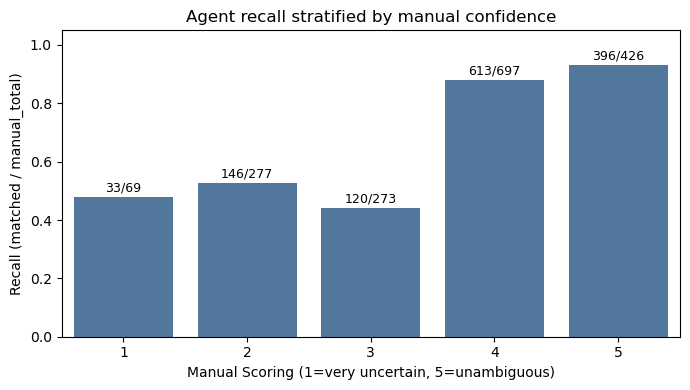

In [6]:
print(score_recall)

fig, ax = plt.subplots(figsize=(7, 4))
sr = score_recall.drop_nulls("manual_scoring").to_pandas()
sns.barplot(data=sr, x="manual_scoring", y="recall", ax=ax, color="#4477AA")
for i, row in sr.iterrows():
    ax.text(i, row["recall"] + 0.02, f"{int(row['matched'])}/{int(row['total'])}",
            ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Manual Scoring (1=very uncertain, 5=unambiguous)")
ax.set_ylabel("Recall (matched / manual_total)")
ax.set_title("Agent recall stratified by manual confidence")
plt.tight_layout()
plt.show()

## Step 5: Spidroin_type confusion matrix

Diagonal = agreement. Off-diagonal cells reveal systematic misclassification, e.g.
human `MaSp` (generic) vs agent `MaSp1/MaSp2/MaSp3` (specific subtype).

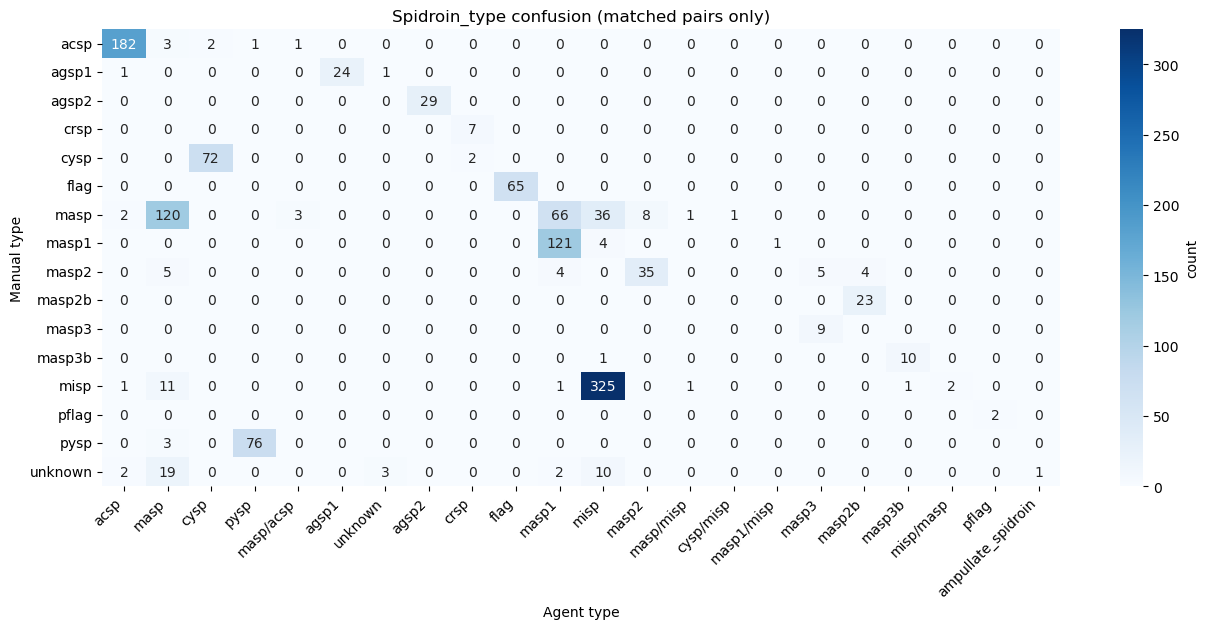

In [7]:
pivot = type_conf.pivot(values="count", index="manual", on="agent", aggregate_function="sum").fill_null(0)
manual_labels = pivot["manual"].to_list()
agent_cols = [c for c in pivot.columns if c != "manual"]
data = pivot.select(agent_cols).to_numpy()

fig, ax = plt.subplots(figsize=(max(8, len(agent_cols) * 0.6), max(6, len(manual_labels) * 0.4)))
sns.heatmap(data, annot=True, fmt="g", cmap="Blues",
            xticklabels=agent_cols, yticklabels=manual_labels, ax=ax, cbar_kws={"label": "count"})
ax.set_xlabel("Agent type")
ax.set_ylabel("Manual type")
ax.set_title("Spidroin_type confusion (matched pairs only)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 6: Full_length and Hint_type agreement

In [8]:
print("--- Full_length confusion ---")
print(fl_conf)
print("\n--- Hint_type confusion ---")
print(hint_conf)

--- Full_length confusion ---
shape: (4, 3)
┌────────┬───────┬───────┐
│ manual ┆ agent ┆ count │
│ ---    ┆ ---   ┆ ---   │
│ bool   ┆ bool  ┆ i64   │
╞════════╪═══════╪═══════╡
│ false  ┆ false ┆ 132   │
│ false  ┆ true  ┆ 41    │
│ true   ┆ true  ┆ 1130  │
│ true   ┆ false ┆ 6     │
└────────┴───────┴───────┘

--- Hint_type confusion ---
shape: (8, 3)
┌─────────────┬─────────────┬───────┐
│ manual      ┆ agent       ┆ count │
│ ---         ┆ ---         ┆ ---   │
│ str         ┆ str         ┆ i64   │
╞═════════════╪═════════════╪═══════╡
│ C-terminal  ┆ C-terminal  ┆ 56    │
│ C-terminal  ┆ Full_length ┆ 1     │
│ Full_length ┆ Full_length ┆ 1166  │
│ Full_length ┆ C-terminal  ┆ 8     │
│ Full_length ┆ N-terminal  ┆ 4     │
│ N-terminal  ┆ N-terminal  ┆ 69    │
│ N-terminal  ┆ Full_length ┆ 4     │
│ N-terminal  ┆ C-terminal  ┆ 1     │
└─────────────┴─────────────┴───────┘


## Step 7: Boundary precision

How close are the agent's start/end coordinates to the manually annotated ones?
`start_diff = agent_start - manual_start` (positive = agent shifted right).

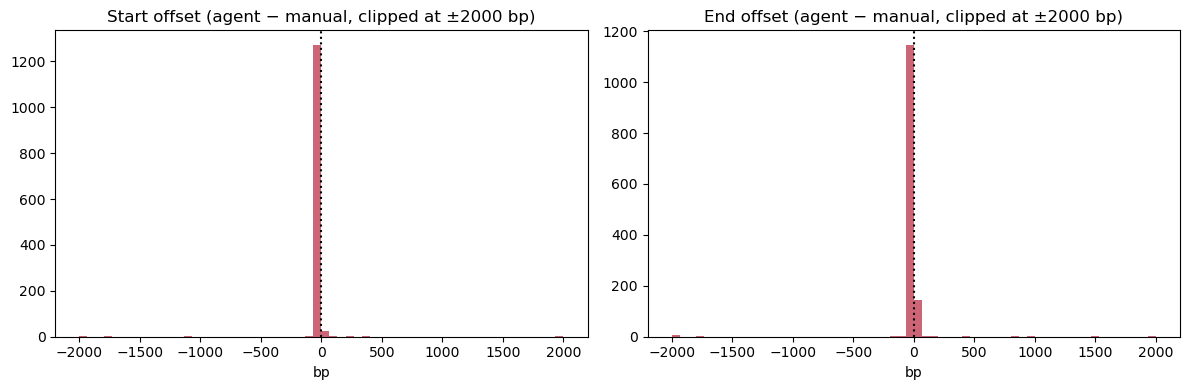

shape: (9, 3)
┌────────────┬─────────────┬─────────────┐
│ statistic  ┆ start_diff  ┆ end_diff    │
│ ---        ┆ ---         ┆ ---         │
│ str        ┆ f64         ┆ f64         │
╞════════════╪═════════════╪═════════════╡
│ count      ┆ 1309.0      ┆ 1309.0      │
│ null_count ┆ 0.0         ┆ 0.0         │
│ mean       ┆ 33.55233    ┆ -47.051948  │
│ std        ┆ 1454.865154 ┆ 1311.408245 │
│ min        ┆ -9527.0     ┆ -46111.0    │
│ 25%        ┆ 0.0         ┆ 0.0         │
│ 50%        ┆ 0.0         ┆ 0.0         │
│ 75%        ┆ 0.0         ┆ 0.0         │
│ max        ┆ 50419.0     ┆ 2481.0      │
└────────────┴─────────────┴─────────────┘


In [9]:
matched = merged.filter(pl.col("match_status") == "matched")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["start_diff", "end_diff"], ["Start offset", "End offset"]):
    vals = matched[col].drop_nulls().to_numpy()
    # clip extreme outliers for visualization
    clip = 2000
    vals_c = vals.clip(-clip, clip)
    ax.hist(vals_c, bins=60, color="#CC6677")
    ax.set_title(f"{title} (agent − manual, clipped at ±{clip} bp)")
    ax.set_xlabel("bp")
    ax.axvline(0, color="black", linestyle=":")
plt.tight_layout()
plt.show()

print(matched.select(["start_diff", "end_diff"]).describe())

## Step 8: Agent confidence vs human Scoring

Sanity check: is the agent's self-reported confidence calibrated against the curator's score?

shape: (2, 7)
┌──────────────────┬──────┬─────┬─────┬─────┬─────┬─────┐
│ agent_confidence ┆ null ┆ 1   ┆ 2   ┆ 3   ┆ 4   ┆ 5   │
│ ---              ┆ ---  ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│ str              ┆ i64  ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
╞══════════════════╪══════╪═════╪═════╪═════╪═════╪═════╡
│ high             ┆ 0    ┆ 1   ┆ 51  ┆ 59  ┆ 578 ┆ 384 │
│ medium           ┆ 0    ┆ 32  ┆ 95  ┆ 61  ┆ 35  ┆ 12  │
└──────────────────┴──────┴─────┴─────┴─────┴─────┴─────┘


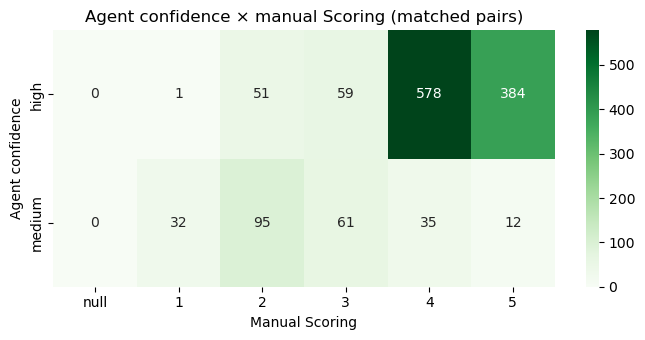

In [10]:
ct = conf_corr.pivot(values="count", index="agent_confidence", on="manual_scoring",
                     aggregate_function="sum").fill_null(0)
print(ct)

score_cols = [c for c in ct.columns if c != "agent_confidence"]
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(ct.select(score_cols).to_numpy(), annot=True, fmt="g", cmap="Greens",
            xticklabels=score_cols, yticklabels=ct["agent_confidence"].to_list(), ax=ax)
ax.set_xlabel("Manual Scoring")
ax.set_ylabel("Agent confidence")
ax.set_title("Agent confidence × manual Scoring (matched pairs)")
plt.tight_layout()
plt.show()

## Step 9: Per-species precision/recall

Species with the lowest recall are the highest-priority for further investigation
(possible missed loci in the agent). Species with low precision and high FP are
agent over-predictions.

In [11]:
# Restrict to species with both sides available
both = sp_summary.filter((pl.col("tp") + pl.col("fn") > 0) & (pl.col("tp") + pl.col("fp") > 0))
print("--- Bottom 15 species by Recall (with both sides) ---")
print(both.sort("recall").head(15).select(["species", "tp", "fn", "fp", "precision", "recall", "f1"]))
print("\n--- Bottom 15 species by Precision (with both sides) ---")
print(both.sort("precision").head(15).select(["species", "tp", "fn", "fp", "precision", "recall", "f1"]))

--- Bottom 15 species by Recall (with both sides) ---
shape: (15, 7)
┌─────────────────────────────┬─────┬─────┬─────┬───────────┬──────────┬──────────┐
│ species                     ┆ tp  ┆ fn  ┆ fp  ┆ precision ┆ recall   ┆ f1       │
│ ---                         ┆ --- ┆ --- ┆ --- ┆ ---       ┆ ---      ┆ ---      │
│ str                         ┆ i64 ┆ i64 ┆ i64 ┆ f64       ┆ f64      ┆ f64      │
╞═════════════════════════════╪═════╪═════╪═════╪═══════════╪══════════╪══════════╡
│ 053.Tibellus sp.2           ┆ 0   ┆ 11  ┆ 15  ┆ 0.0       ┆ 0.0      ┆ null     │
│ 035.Phrurolithus hamatus    ┆ 0   ┆ 4   ┆ 5   ┆ 0.0       ┆ 0.0      ┆ null     │
│ 063.Araneus marmoreus       ┆ 0   ┆ 22  ┆ 39  ┆ 0.0       ┆ 0.0      ┆ null     │
│ 034.Pholcus sp              ┆ 0   ┆ 1   ┆ 2   ┆ 0.0       ┆ 0.0      ┆ null     │
│ 042.Psilodercidae sp        ┆ 0   ┆ 1   ┆ 5   ┆ 0.0       ┆ 0.0      ┆ null     │
│ …                           ┆ …   ┆ …   ┆ …   ┆ …         ┆ …        ┆ …        │
│ 069.A

## Step 10: Discrepancies that deserve human review

Prioritize disagreements on high-Scoring loci (where the human was confident).

In [12]:
# Manual high-confidence calls (Scoring >= 4) that disagree with the agent
hi_disc = discrepancies.filter(
    (pl.col("manual_scoring") >= 4)
    & ((pl.col("match_status") == "manual_only")
       | (pl.col("type_agree") == False)
       | (pl.col("full_length_agree") == False))
).sort(["manual_scoring", "species"], descending=[True, False])

print(f"High-Scoring disagreements: {len(hi_disc)}")
print(hi_disc.select([
    "species", "chr", "strand", "match_status",
    "manual_id", "manual_type", "manual_full_length", "manual_scoring",
    "agent_id", "agent_type", "agent_full_length", "agent_confidence",
]).head(30))

High-Scoring disagreements: 284
shape: (30, 12)
┌────────────┬───────┬────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ species    ┆ chr   ┆ strand ┆ match_stat ┆ … ┆ agent_id   ┆ agent_type ┆ agent_full ┆ agent_conf │
│ ---        ┆ ---   ┆ ---    ┆ us         ┆   ┆ ---        ┆ ---        ┆ _length    ┆ idence     │
│ str        ┆ str   ┆ str    ┆ ---        ┆   ┆ str        ┆ str        ┆ ---        ┆ ---        │
│            ┆       ┆        ┆ str        ┆   ┆            ┆            ┆ bool       ┆ str        │
╞════════════╪═══════╪════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 002.Anypha ┆ chr01 ┆ -      ┆ matched    ┆ … ┆ Anbo_spid_ ┆ misp       ┆ true       ┆ high       │
│ ena        ┆       ┆        ┆            ┆   ┆ 00009      ┆            ┆            ┆            │
│ bomiensis  ┆       ┆        ┆            ┆   ┆            ┆            ┆            ┆            │
│ 004.Borbor ┆ chr15 ┆ +      ┆ matched    

## Step 11: Build HTML report with figures

Render the 9 figures + self-contained HTML report at `reports/agent_vs_manual_report.html`.
The HTML embeds all images as base64 so it can be shared as a single file.

In [13]:
html_path = PROJ_ROOT / "reports" / "agent_vs_manual_report.html"
fig_dir = PROJ_ROOT / "reports" / "figures" / "agent_vs_manual"

run_cmd(
    f"pixi run python -m spider_silkome_module.build_comparison_report \
        --comparison-dir {output_dir} \
        --fig-dir {fig_dir} \
        --html-path {html_path} \
        --min-overlap {MIN_OVERLAP}",
    outputs=[html_path],
    force=True,
)

print(f"HTML report: {html_path}")
print(f"Figures dir: {fig_dir}")

2026-05-19 22:08:10.338 | INFO     | spider_silkome_module.config:<module>:11 - PROJ_ROOT path is: /home/gyk/project/spider_silkome


2026-05-19 22:08:11.904 | INFO     | __main__:main:678 - Reading comparison TSVs from /home/gyk/project/spider_silkome/results/comparison
2026-05-19 22:08:11.930 | INFO     | __main__:main:689 - Generating figures into /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual
2026-05-19 22:08:17.459 | INFO     | __main__:main:702 -   species_coverage: /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual/01_species_coverage.png
2026-05-19 22:08:17.459 | INFO     | __main__:main:702 -   locus_metrics: /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual/02_locus_metrics.png
2026-05-19 22:08:17.459 | INFO     | __main__:main:702 -   scoring_recall: /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual/03_scoring_recall.png
2026-05-19 22:08:17.460 | INFO     | __main__:main:702 -   type_confusion: /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual/04_type_confusion.png
2026-05-19 22:08:17.460 | INFO     | __main__:main:702 -   full_le

HTML report: /home/gyk/project/spider_silkome/reports/agent_vs_manual_report.html
Figures dir: /home/gyk/project/spider_silkome/reports/figures/agent_vs_manual


## Step 12: (Optional) Publish to Cloudflare Pages

Push the HTML report to a stable, shareable URL (e.g. for pasting into Yuque).

**One-time setup**: a browser window opens for Cloudflare login (free account).
Subsequent runs reuse the saved credentials and **update the same URL**, so the
link your advisor bookmarks always points to the latest version.

Run the cell below from a terminal (or via the `!` shell magic shown), since
the first call requires interactive browser auth.

In [ ]:
# Run from a terminal at the project root (interactive browser auth on first run):
#
#     pixi run python scripts/publish_report.py
#
# Or uncomment the line below to invoke from the notebook (won't survive a kernel restart):
# !pixi run python {PROJ_ROOT}/scripts/publish_report.py

publish_cmd = f"pixi run python {PROJ_ROOT}/scripts/publish_report.py"
print("Run this in a terminal to publish/update the report:")
print(f"  {publish_cmd}")


## Results summary

TSV artifacts under `results/comparison/`:

- `merged_loci.tsv` — long-form locus pairs (matched / manual_only / agent_only)
- `species_coverage.tsv` — per-species side classification
- `species_summary.tsv` — per-species TP/FP/FN/precision/recall/F1
- `type_confusion.tsv`, `full_length_confusion.tsv`, `hint_type_confusion.tsv`
- `boundary_stats.tsv` — start/end offset distribution
- `scoring_recall.tsv` — recall stratified by manual Scoring
- `confidence_correlation.tsv` — agent confidence × manual Scoring
- `discrepancies.tsv` — full disagreement table for human review
- `report.md` — human-readable summary

Visualization artifacts under `reports/`:

- `reports/figures/agent_vs_manual/01-09_*.png` — 9 standalone figures
- `reports/agent_vs_manual_report.html` — self-contained HTML report (open in any browser)

Sharing:

- Run `pixi run python scripts/publish_report.py` to deploy the HTML to Cloudflare Pages
  and get a stable public URL you can paste into Yuque/Feishu (see Step 12)
